# IPL 2026 — Match Prediction Interface

Uses the trained ensemble model (LightGBM + CatBoost + XGBoost) to predict IPL 2026 match winners.

**Sections**
1. Load & Setup
2. Pre-Match Prediction
3. Match Insight Cards
4. Post-Match Result Logger
5. Season Tracker

> Run `training.ipynb` first to generate model artifacts in `Models/`.

## 1. Load & Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

# Locate project root
for _p in [Path().resolve(), *Path().resolve().parents]:
    if (_p / 'project_paths.py').is_file():
        sys.path.insert(0, str(_p))
        break
from project_paths import DATASET_DIR, MODEL_DIR

# Try ensemble first, fall back to XGBoost for backward compatibility
if (MODEL_DIR / 'ensemble_ipl_model.pkl').exists():
    model = joblib.load(MODEL_DIR / 'ensemble_ipl_model.pkl')
    print('Loaded: ensemble_ipl_model.pkl')
else:
    model = joblib.load(MODEL_DIR / 'xgb_ipl_model.pkl')
    print('Loaded: xgb_ipl_model.pkl (fallback)')

feature_cols  = joblib.load(MODEL_DIR / 'feature_columns.pkl')
team_name_map = joblib.load(MODEL_DIR / 'team_name_map.pkl')
elo_ratings   = joblib.load(MODEL_DIR / 'elo_ratings.pkl') if (MODEL_DIR / 'elo_ratings.pkl').exists() else {}

# Load datasets
matches            = pd.read_csv(DATASET_DIR / 'matches.csv', low_memory=False)
player_match_stats = pd.read_csv(DATASET_DIR / 'player_match_stats.csv', low_memory=False)

# Standardise column names
matches.columns = matches.columns.str.lower().str.replace(' ', '_')
_col_renames = {'match_winner': 'winner', 'match_date': 'date', 'matchid': 'match_id'}
matches.rename(columns={k: v for k, v in _col_renames.items() if k in matches.columns}, inplace=True)
matches['date'] = pd.to_datetime(matches['date'], errors='coerce')
for col in ['team1', 'team2', 'winner', 'toss_winner']:
    if col in matches.columns:
        matches[col] = matches[col].replace(team_name_map)
if 'date' in player_match_stats.columns:
    player_match_stats['date'] = pd.to_datetime(player_match_stats['date'], errors='coerce')

IPL_2026_TEAMS = [
    'Mumbai Indians', 'Chennai Super Kings', 'Royal Challengers Bengaluru',
    'Kolkata Knight Riders', 'Delhi Capitals', 'Sunrisers Hyderabad',
    'Rajasthan Royals', 'Punjab Kings', 'Lucknow Super Giants', 'Gujarat Titans',
]

HOME_CITY = {
    'Mumbai Indians': 'Mumbai', 'Chennai Super Kings': 'Chennai',
    'Royal Challengers Bengaluru': 'Bengaluru', 'Kolkata Knight Riders': 'Kolkata',
    'Delhi Capitals': 'Delhi', 'Sunrisers Hyderabad': 'Hyderabad',
    'Rajasthan Royals': 'Jaipur', 'Punjab Kings': 'Chandigarh',
    'Lucknow Super Giants': 'Lucknow', 'Gujarat Titans': 'Ahmedabad',
}

print(f'Matches: {len(matches):,} | Players tracked: {player_match_stats["player"].nunique()}')
print(f'Features: {len(feature_cols)} | Elo teams: {len(elo_ratings)}')
print('\nReady to predict!')

Loaded: ensemble_ipl_model.pkl
Matches: 1,169 | Players tracked: 767
Features: 31 | Elo teams: 14

Ready to predict!


In [2]:
# --- Helper functions used by all sections ---

def _safe(val, default):
    return val if pd.notna(val) and np.isfinite(val) else default


def get_form(team, n=5):
    """Recent win rate and W/L string for a team."""
    valid = matches.dropna(subset=['winner'])
    past  = valid[(valid['team1'] == team) | (valid['team2'] == team)].tail(n)
    if len(past) == 0:
        return 0.5, 'UUUUU'
    form_str = ''.join('W' if r['winner'] == team else 'L' for _, r in past.iterrows())
    return (past['winner'] == team).mean(), form_str


def get_season_form(team, season, n=3):
    """Win rate in the current season (last n matches)."""
    valid = matches.dropna(subset=['winner'])
    past  = valid[((valid['team1'] == team) | (valid['team2'] == team))
                  & (valid['season'] == season)].tail(n)
    return (past['winner'] == team).mean() if len(past) > 0 else 0.5


def get_momentum(team, n=5):
    """Exponentially-weighted win streak score."""
    valid   = matches.dropna(subset=['winner'])
    past    = valid[(valid['team1'] == team) | (valid['team2'] == team)].tail(n)
    if len(past) == 0:
        return 0.5
    outcomes = [(1.0 if r['winner'] == team else 0.0) for _, r in past.iterrows()]
    weights  = np.exp(np.linspace(0, 1, len(outcomes)))
    return float(np.average(outcomes, weights=weights))


def get_h2h(team1, team2):
    """Head-to-head record between two teams."""
    valid = matches.dropna(subset=['winner'])
    h2h   = valid[((valid['team1'] == team1) & (valid['team2'] == team2))
                  | ((valid['team1'] == team2) & (valid['team2'] == team1))]
    return int((h2h['winner'] == team1).sum()), int((h2h['winner'] == team2).sum()), len(h2h)


def get_venue_stats(venue, team1, team2):
    """Venue batting-first win % and per-team win % at this venue."""
    valid = matches.dropna(subset=['winner'])
    v     = valid[valid['venue'] == venue]
    if len(v) == 0:
        return {'total': 0, 'bat_first_pct': 0.5, 't1_pct': 0.5, 't2_pct': 0.5}
    bat   = v[v['toss_decision'] == 'bat']
    bfwp  = (bat['toss_winner'] == bat['winner']).mean() if len(bat) > 0 else 0.5
    t1v   = v[(v['team1'] == team1) | (v['team2'] == team1)]
    t2v   = v[(v['team1'] == team2) | (v['team2'] == team2)]
    return {
        'total':       len(v),
        'bat_first_pct': float(bfwp),
        't1_pct': float((t1v['winner'] == team1).mean()) if len(t1v) > 0 else 0.5,
        't2_pct': float((t2v['winner'] == team2).mean()) if len(t2v) > 0 else 0.5,
    }


def get_player_strength(team):
    """Batting/bowling metrics for team's most recently seen players."""
    data = player_match_stats[player_match_stats['team'] == team]
    if len(data) == 0:
        return dict(sr=120.0, avg=25.0, econ=8.5, exp=10, bpct=0.3)
    b = data[data['balls_faced'].fillna(0) > 0]
    w = data[data['balls_bowled'].fillna(0) > 0]
    return {
        'sr':   _safe(b['strike_rate'].mean(), 120.0),
        'avg':  _safe(b['runs_scored'].mean(),  25.0),
        'econ': _safe(w['economy'].mean(),        8.5),
        'exp':  int(data['player'].nunique()),
        'bpct': _safe(b['boundary_pct'].mean(), 0.3),
    }


def build_features(team1, team2, venue, toss_winner, toss_decision, city='', season=2026):
    """Build one-row feature DataFrame for model prediction."""
    form1, _ = get_form(team1)
    form2, _ = get_form(team2)
    sf1      = get_season_form(team1, season)
    sf2      = get_season_form(team2, season)
    mo1      = get_momentum(team1)
    mo2      = get_momentum(team2)
    h1, h2, ht = get_h2h(team1, team2)
    vs       = get_venue_stats(venue, team1, team2)
    ps1      = get_player_strength(team1)
    ps2      = get_player_strength(team2)
    elo1     = elo_ratings.get(team1, 1500.0)
    elo2     = elo_ratings.get(team2, 1500.0)
    home1    = int(HOME_CITY.get(team1, '') in city)
    home2    = int(HOME_CITY.get(team2, '') in city)

    feat = {
        'elo_team1': elo1, 'elo_team2': elo2, 'elo_diff': elo1 - elo2,
        'team1_form_last5': form1, 'team2_form_last5': form2,
        'team1_season_form': sf1,  'team2_season_form': sf2,
        'team1_momentum': mo1,     'team2_momentum': mo2,
        'h2h_team1_wins': h1,      'h2h_team2_wins': h2, 'h2h_total': ht,
        'venue_bat_first_win_pct': vs['bat_first_pct'],
        'venue_team1_win_pct': vs['t1_pct'],
        'venue_team2_win_pct': vs['t2_pct'],
        'toss_winner_is_team1': int(toss_winner == team1),
        'toss_decision_bat': int(toss_decision.lower() in ('bat', 'batting')),
        'team1_home': home1, 'team2_home': home2,
        'team1_avg_sr': ps1['sr'],   'team1_avg_avg': ps1['avg'],
        'team1_avg_econ': ps1['econ'], 'team1_experience': ps1['exp'],
        'team1_boundary_pct': ps1['bpct'],
        'team2_avg_sr': ps2['sr'],   'team2_avg_avg': ps2['avg'],
        'team2_avg_econ': ps2['econ'], 'team2_experience': ps2['exp'],
        'team2_boundary_pct': ps2['bpct'],
        'season': season,
        'is_playoff': 0,
    }

    # Align with training features — fill missing with 0.5, drop extras
    row = {k: feat.get(k, 0.5) for k in feature_cols}
    X   = pd.DataFrame([row])[feature_cols]
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(X.median(), inplace=True)
    return X


print('Helper functions ready.')

Helper functions ready.


## 2. Pre-Match Prediction

Edit the match details below, then run the cell.

In [3]:
# ============================================================
# EDIT THESE VALUES
# ============================================================
TEAM1         = 'Mumbai Indians'
TEAM2         = 'Chennai Super Kings'
VENUE         = 'Wankhede Stadium'
CITY          = 'Mumbai'
TOSS_WINNER   = 'Mumbai Indians'
TOSS_DECISION = 'bat'   # 'bat' or 'field'
SEASON        = 2026
# ============================================================

# Standardise team names
TEAM1 = team_name_map.get(TEAM1, TEAM1)
TEAM2 = team_name_map.get(TEAM2, TEAM2)

X = build_features(TEAM1, TEAM2, VENUE, TOSS_WINNER, TOSS_DECISION, city=CITY, season=SEASON)
proba = model.predict_proba(X)[0]
p1    = float(proba[1])   # prob team1 wins
p2    = float(proba[0])   # prob team2 wins
winner    = TEAM1 if p1 > p2 else TEAM2
confidence = max(p1, p2)

print('=' * 62)
print(f'  IPL 2026 MATCH PREDICTION')
print(f'  {TEAM1}  vs  {TEAM2}')
print(f'  Venue : {VENUE}')
print(f'  Toss  : {TOSS_WINNER} chose to {TOSS_DECISION}')
print('=' * 62)
print(f'\n  Predicted winner : {winner}')
print(f'  Confidence       : {confidence:.1%}')
print(f'\n  {TEAM1:40s} {p1:.1%}')
print(f'  {TEAM2:40s} {p2:.1%}')
print('=' * 62)

  IPL 2026 MATCH PREDICTION
  Mumbai Indians  vs  Chennai Super Kings
  Venue : Wankhede Stadium
  Toss  : Mumbai Indians chose to bat

  Predicted winner : Chennai Super Kings
  Confidence       : 70.2%

  Mumbai Indians                           29.8%
  Chennai Super Kings                      70.2%


  File "c:\Users\saite\anaconda3\envs\ipl\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\saite\anaconda3\envs\ipl\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\saite\anaconda3\envs\ipl\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\saite\anaconda3\envs\ipl\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\saite\anaconda3\envs\ipl\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


## 3. Match Insight Cards

Visualises team form, H2H, and venue stats for the match above.

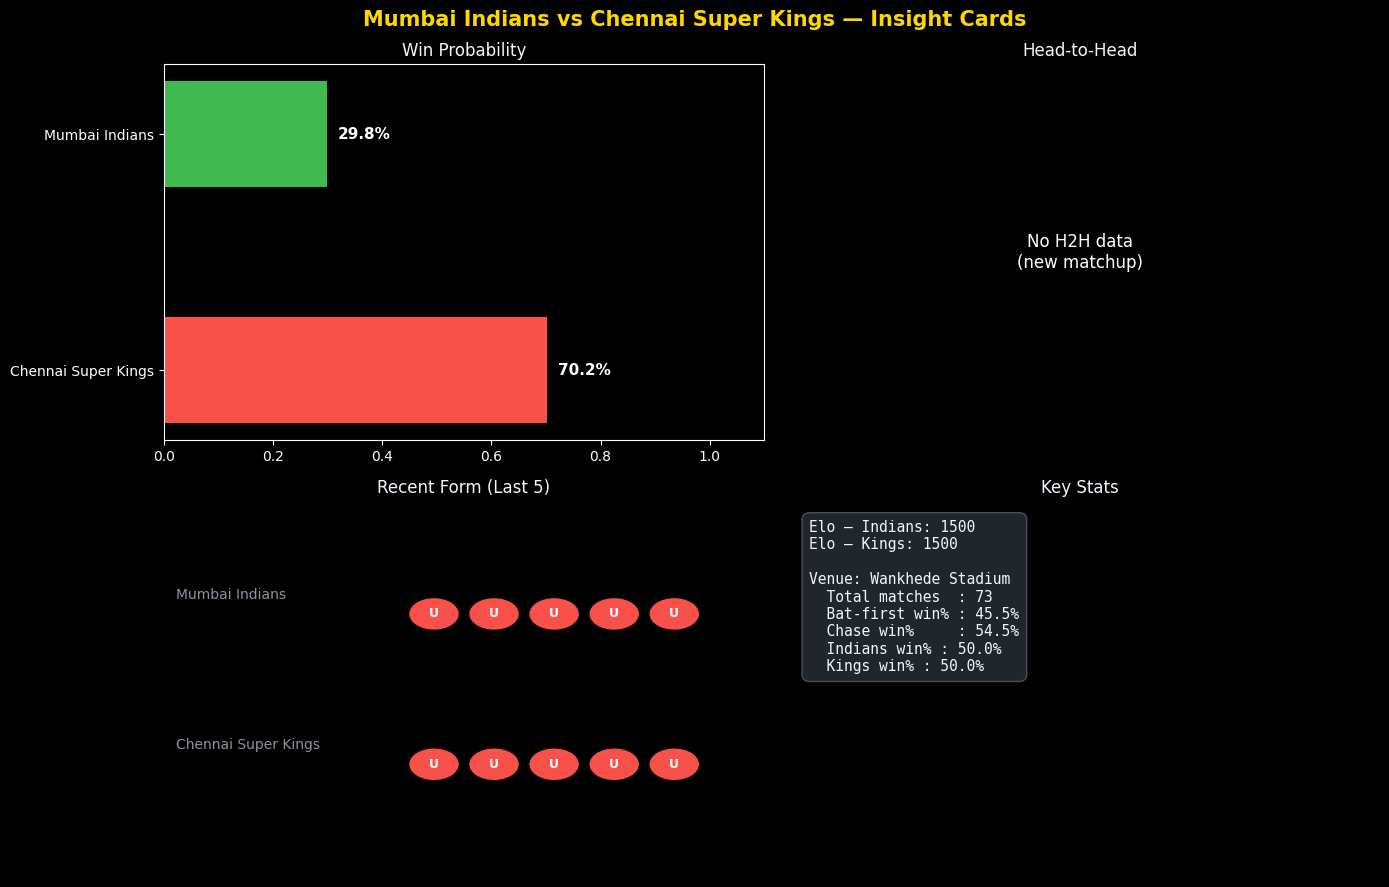

In [4]:
form1_rate, form1_str = get_form(TEAM1)
form2_rate, form2_str = get_form(TEAM2)
h2h_t1, h2h_t2, h2h_total = get_h2h(TEAM1, TEAM2)
vs    = get_venue_stats(VENUE, TEAM1, TEAM2)
elo1  = elo_ratings.get(TEAM1, 1500)
elo2  = elo_ratings.get(TEAM2, 1500)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f'{TEAM1} vs {TEAM2} — Insight Cards',
             fontsize=15, fontweight='bold', color='#FFD700')

# 1. Win probability bar
ax = axes[0, 0]
ax.barh([TEAM2, TEAM1], [p2, p1], color=['#F85149', '#3FB950'],
        edgecolor='none', height=0.45)
ax.set_xlim(0, 1.1)
ax.set_title('Win Probability', color='#F0F6FC')
for val, label in [(p2, TEAM2), (p1, TEAM1)]:
    ax.text(val + 0.02, [TEAM2, TEAM1].index(label),
            f'{val:.1%}', va='center', fontweight='bold', fontsize=11)

# 2. Head-to-Head
ax = axes[0, 1]
if h2h_total > 0:
    ax.pie([h2h_t1, h2h_t2],
           labels=[f'{TEAM1}\n({h2h_t1} wins)', f'{TEAM2}\n({h2h_t2} wins)'],
           autopct='%1.0f%%', colors=['#3FB950', '#F85149'],
           startangle=90, textprops={'fontsize': 10})
    ax.set_title(f'Head-to-Head ({h2h_total} matches)', color='#F0F6FC')
else:
    ax.text(0.5, 0.5, 'No H2H data\n(new matchup)', ha='center', va='center', fontsize=12)
    ax.set_title('Head-to-Head', color='#F0F6FC')
    ax.axis('off')

# 3. Recent form (colour-coded W/L dots)
ax = axes[1, 0]
ax.axis('off')
ax.set_title('Recent Form (Last 5)', color='#F0F6FC')
for row_i, (team, fstr) in enumerate([(TEAM1, form1_str), (TEAM2, form2_str)]):
    y = 0.7 - row_i * 0.4
    ax.text(0.02, y + 0.05, f'{team}', transform=ax.transAxes,
            fontsize=10, color='#8B949E', va='center')
    for ci, ch in enumerate(fstr[-5:]):
        col = '#3FB950' if ch == 'W' else '#F85149'
        ax.add_patch(plt.Circle((0.45 + ci * 0.1, y), 0.04,
                                transform=ax.transAxes, color=col, clip_on=False))
        ax.text(0.45 + ci * 0.1, y, ch, transform=ax.transAxes,
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')

# 4. Elo & venue stats
ax = axes[1, 1]
ax.axis('off')
ax.set_title('Key Stats', color='#F0F6FC')
stats_text = (
    f'Elo — {TEAM1.split()[-1]}: {elo1:.0f}\n'
    f'Elo — {TEAM2.split()[-1]}: {elo2:.0f}\n\n'
    f'Venue: {VENUE}\n'
    f'  Total matches  : {vs["total"]}\n'
    f'  Bat-first win% : {vs["bat_first_pct"]:.1%}\n'
    f'  Chase win%     : {1 - vs["bat_first_pct"]:.1%}\n'
    f'  {TEAM1.split()[-1]} win% : {vs["t1_pct"]:.1%}\n'
    f'  {TEAM2.split()[-1]} win% : {vs["t2_pct"]:.1%}'
)
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
        fontsize=10.5, va='top', fontfamily='monospace', color='#F0F6FC',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#21262D', edgecolor='#484F58'))

plt.tight_layout()
plt.show()

In [5]:
# Optional: generate a shareable prediction card image
# Requires: pip install Pillow  (already in requirements.txt)

try:
    from video_card import generate_prediction_card
    from datetime import date as _date

    saved = generate_prediction_card(
        team1=TEAM1, team2=TEAM2, venue=VENUE,
        predicted_winner=winner,
        win_prob_team1=p1, win_prob_team2=p2,
        h2h=(h2h_t1, h2h_t2),
        form_team1=form1_str, form_team2=form2_str,
        venue_win_pct_team1=vs['t1_pct'] * 100,
        venue_win_pct_team2=vs['t2_pct'] * 100,
        date=str(_date.today()),
        confidence=confidence * 100,
    )
    print(f'Prediction card saved → {saved}')
except ImportError:
    print('video_card.py not found. Skipping card generation.')

Prediction card saved → D:\Projects\IPL 2026\output\prediction_card_Mumbai_Indians_vs_Chennai_Super_Kings_2026-03-28.png
Prediction card saved → D:\Projects\IPL 2026\output\prediction_card_Mumbai_Indians_vs_Chennai_Super_Kings_2026-03-28.png


## 4. Post-Match Result Logger

After the match is played, add the result here to keep the dataset current.
Restart the kernel after running this cell so the updated data is used.

In [6]:
# ============================================================
# EDIT: Add completed match results, then run this cell
# ============================================================
new_matches = [
    # Uncomment and fill in after the match:
    # {
    #     'id': 10001,              # unique match ID (increment from last)
    #     'city': 'Mumbai',
    #     'date': '2026-03-28',
    #     'season': 2026,
    #     'team1': 'Mumbai Indians',
    #     'team2': 'Chennai Super Kings',
    #     'venue': 'Wankhede Stadium',
    #     'toss_winner': 'Mumbai Indians',
    #     'toss_decision': 'bat',
    #     'winner': 'Mumbai Indians',
    #     'result': 'runs',         # 'runs' or 'wickets'
    #     'win_by_runs': 15,
    #     'win_by_wickets': 0,
    #     'player_of_match': 'Rohit Sharma',
    # },
]
# ============================================================

if len(new_matches) > 0:
    new_df   = pd.DataFrame(new_matches)
    existing = pd.read_csv(DATASET_DIR / 'matches.csv')
    updated  = pd.concat([existing, new_df], ignore_index=True)
    updated.to_csv(DATASET_DIR / 'matches.csv', index=False)
    print(f'Added {len(new_matches)} match(es). Total: {len(updated)}')
    print('Restart kernel (Kernel > Restart) so updated data loads.')
else:
    print('No new matches. Uncomment and fill in match results above.')

No new matches. Uncomment and fill in match results above.


## 5. Season Tracker

Running tally of IPL 2026 predictions vs actual results.
Add actual results to `season_log` as the season progresses.

In [7]:
# ============================================================
# EDIT: Add rows as matches are predicted and results known
# ============================================================
season_log = [
    # {'date': '2026-03-22', 'team1': 'KKR', 'team2': 'RCB',
    #  'predicted': 'KKR', 'actual': 'RCB', 'confidence': 0.58},
]
# ============================================================

if len(season_log) == 0:
    print('No season predictions logged yet.')
    print('Add entries to season_log after each match.')
else:
    log_df = pd.DataFrame(season_log)
    log_df['correct'] = log_df['predicted'] == log_df['actual']
    total     = len(log_df)
    correct   = log_df['correct'].sum()
    acc       = correct / total
    avg_conf  = log_df['confidence'].mean()

    print(f'IPL 2026 Season Tracker  ({total} matches predicted)')
    print(f'  Correct   : {correct}/{total}  ({acc:.1%})')
    print(f'  Avg confidence: {avg_conf:.1%}')
    print()
    display(log_df[['date', 'team1', 'team2', 'predicted', 'actual', 'confidence', 'correct']])

    # Plot accuracy over time
    if total >= 3:
        running_acc = log_df['correct'].expanding().mean()
        plt.figure(figsize=(10, 4))
        plt.plot(range(1, total + 1), running_acc, marker='o', color='#00D4AA', linewidth=2)
        plt.axhline(0.5, color='#F85149', linestyle='--', alpha=0.7, label='50% baseline')
        plt.xlabel('Match #')
        plt.ylabel('Running Accuracy')
        plt.title('IPL 2026 — Prediction Accuracy Over Season', color='#FFD700')
        plt.legend()
        plt.tight_layout()
        plt.show()

No season predictions logged yet.
Add entries to season_log after each match.
